# Import needed modules

In [1]:
# Use pre-installed high-performance TensorFlow with GPU support


In [2]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# Create needed functions

## Functions to Create Data Frame from Dataset

#### **Function to create data frame**

In [3]:
# Generate data paths with labels
def define_paths(data_dir):
    filepaths = []
    labels = []

    folds = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = [img for img in os.listdir(foldpath) if img.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe
def define_df(files, classes):
    Fseries = pd.Series(files, name='filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis=1)

# Split dataframe to train, valid, and test
def split_data(data_dir):
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df['labels']
    train_df, dummy_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123, stratify=strat)

    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=123, stratify=strat)

    return train_df, valid_df, test_df


#### Function to generate images from dataframe

In [4]:
def create_gens (train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframe and fit them into image data generator, because model takes data from image data generator.
    Image data generator converts images into tensors. '''


    # define model parameters
    img_size = (224, 224)
    channels = 3 # either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Recommended : use custom function for test data batch size, else we can use normal batch size.
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size

    # This function which will be used in image data generator for data augmentation, it just take the image and return it again.
    def scalar(img):
        return img

    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)

    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    # Note: we will use custom test_batch_size, and make shuffle= false
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= False, batch_size= test_batch_size)

    return train_gen, valid_gen, test_gen

#### **Function to display data sample**

In [5]:
def show_images(gen):
    '''
    Displays a sample grid of images from the image generator.
    '''
    g_dict = gen.class_indices
    classes = list(g_dict.keys())
    images, labels = next(gen)

    sample = min(len(labels), 16)
    plt.figure(figsize=(14, 14))

    for i in range(sample):
        plt.subplot(4, 4, i + 1)
        img_arr = images[i].copy()
        if img_arr.max() > 1.0:
            img_arr = img_arr / 255.0
        plt.imshow(img_arr)
        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color='blue', fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


#### **Callbacks** 
<br> 
Callbacks : Helpful functions to help optimize model training  <br> 
Examples: stop model training after specfic time, stop training if no improve in accuracy and so on.

In [6]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.model = model
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to run per epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        self.best_weights = self.model.get_weights() # set best weights to model's initial weights
        self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
        msg = 'Do you want model asks you to halt the training [y/n] ?'
        print(msg)
        ans = input('')
        if ans in ['Y', 'y']:
            self.ask_permission = 1
        elif ans in ['N', 'n']:
            self.ask_permission = 0

        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()


    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        # set the weights of the model to the best weights
        self.model.set_weights(self.best_weights)


    def on_train_batch_end(self, batch, logs= None):
        # get batch accuracy and loss
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')

        # prints over on the same line to show running batch count
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '')


    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()


    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr)) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer

                else:
                    self.count = self.count + 1 # increment the patience counter

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

        else:
            if self.ask_epoch != None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
                    print(msg)

                    ans = input('')
                    if ans == 'H' or ans == 'h':
                        msg = f'training has been halted at epoch {epoch + 1} due to user input'
                        print(msg)
                        self.model.stop_training = True # stop training

                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            msg = f' training will continue until epoch {str(self.ask_epoch)}'
                            print(msg)
                            msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
                            print(msg)

                        except Exception:
                            print('Invalid')

#### **Function to plot history of training**

In [7]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()


#### **Function to create Confusion Matrix**

In [8]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
	'''
	This function plot confusion matrix method from sklearn package.
	'''

	plt.figure(figsize= (10, 10))
	plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
	plt.title(title)
	plt.colorbar()

	tick_marks = np.arange(len(classes))
	plt.xticks(tick_marks, classes, rotation= 45)
	plt.yticks(tick_marks, classes)

	if normalize:
		cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
		print('Normalized Confusion Matrix')

	else:
		print('Confusion Matrix, Without Normalization')

	print(cm)

	thresh = cm.max() / 2.
	for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
		plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

	plt.tight_layout()
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')

# **Model Structure**

#### **Start Reading Dataset**

In [9]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (Eye Diseases Dataset)
# ====================================================================
import os
import glob
import pandas as pd
import numpy as np

data_dir = None

print('🔍 Inspecting Kaggle environment and searching for Eye Diseases dataset...')

# 1. Print directories in /kaggle/input if available
if os.path.exists('/kaggle/input'):
    input_items = os.listdir('/kaggle/input')
    print(f'📂 Mounted directories in /kaggle/input ({len(input_items)}): {input_items}')
else:
    print('📂 /kaggle/input not present (running locally).')

# 2. Universal Eye Disease Finder: Walk through any directory tree and find folders with 4+ class subdirectories
def find_eye_disease_root(search_path):
    if not os.path.exists(search_path):
        return None
    for root, dirs, files in os.walk(search_path):
        dirs_lower = [d.lower().strip() for d in dirs]
        # Look for typical eye disease class names
        if any(c in dirs_lower for c in ['cataract', 'glaucoma', 'diabetic_retinopathy', 'normal']):
            img_count = 0
            for d in dirs:
                sub_path = os.path.join(root, d)
                try:
                    imgs = [f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                    if len(imgs) > 0:
                        img_count += 1
                except Exception:
                    pass
            if img_count >= 2:
                return root
    return None

# Search mounted paths & local datasets
search_locations = ['/kaggle/input', '../input', '../datasets', './datasets', '.']
for loc in search_locations:
    found = find_eye_disease_root(loc)
    if found:
        data_dir = found
        print(f'✅ Found Eye Disease dataset at: {data_dir}')
        break

# 3. If not found in mounted directories, auto-download via KaggleHub
if not data_dir:
    print('⚡ Dataset not detected in mounted inputs. Attempting KaggleHub download...')
    for slug in ['gunavenkat/eye-diseases-classification', 'kondwani/eye-disease-dataset']:
        try:
            import kagglehub
            dl_path = kagglehub.dataset_download(slug)
            print(f'✅ Downloaded {slug} to: {dl_path}')
            found = find_eye_disease_root(dl_path)
            if found:
                data_dir = found
                break
        except Exception as e:
            print(f'⚠️ KaggleHub notice on {slug}: {e}')

# 4. Final verification and Generator construction
if not data_dir or not os.path.exists(data_dir):
    print('❌ ERROR: Eye Disease dataset could not be found.')
    if os.path.exists('/kaggle/input'):
        print('📂 Available items in /kaggle/input:')
        for item in os.listdir('/kaggle/input'):
            print('  -', item)
    raise FileNotFoundError(
        'Eye disease dataset not found. Please attach "gunavenkat/eye-diseases-classification" '
        'or "kondwani/eye-disease-dataset" via Kaggle "+ Add Input", or enable Internet in Notebook Settings.'
    )

print(f'📂 Final Resolved data_dir: {data_dir}')

# Build DataFrame splits and data generators
train_df, valid_df, test_df = split_data(data_dir)
batch_size = 40
train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

print(f'🎉 Success! Generators ready:')
print(f'   • Train images:      {len(train_df)}')
print(f'   • Validation images: {len(valid_df)}')
print(f'   • Test images:       {len(test_df)}')
print(f'   • Classes ({len(train_gen.class_indices)}): {list(train_gen.class_indices.keys())}')


🔍 Inspecting Kaggle environment and searching for Eye Diseases dataset...
📂 Mounted directories in /kaggle/input (1): ['datasets']
✅ Found Eye Disease dataset at: /kaggle/input/datasets/kondwani/eye-disease-dataset/Eye_diseases
📂 Final Resolved data_dir: /kaggle/input/datasets/kondwani/eye-disease-dataset/Eye_diseases
Found 306 validated image filenames belonging to 5 classes.
Found 38 validated image filenames belonging to 5 classes.
Found 39 validated image filenames belonging to 5 classes.
🎉 Success! Generators ready:
   • Train images:      306
   • Validation images: 38
   • Test images:       39
   • Classes (5): ['Bulging_Eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']


#### **Display Image Sample**

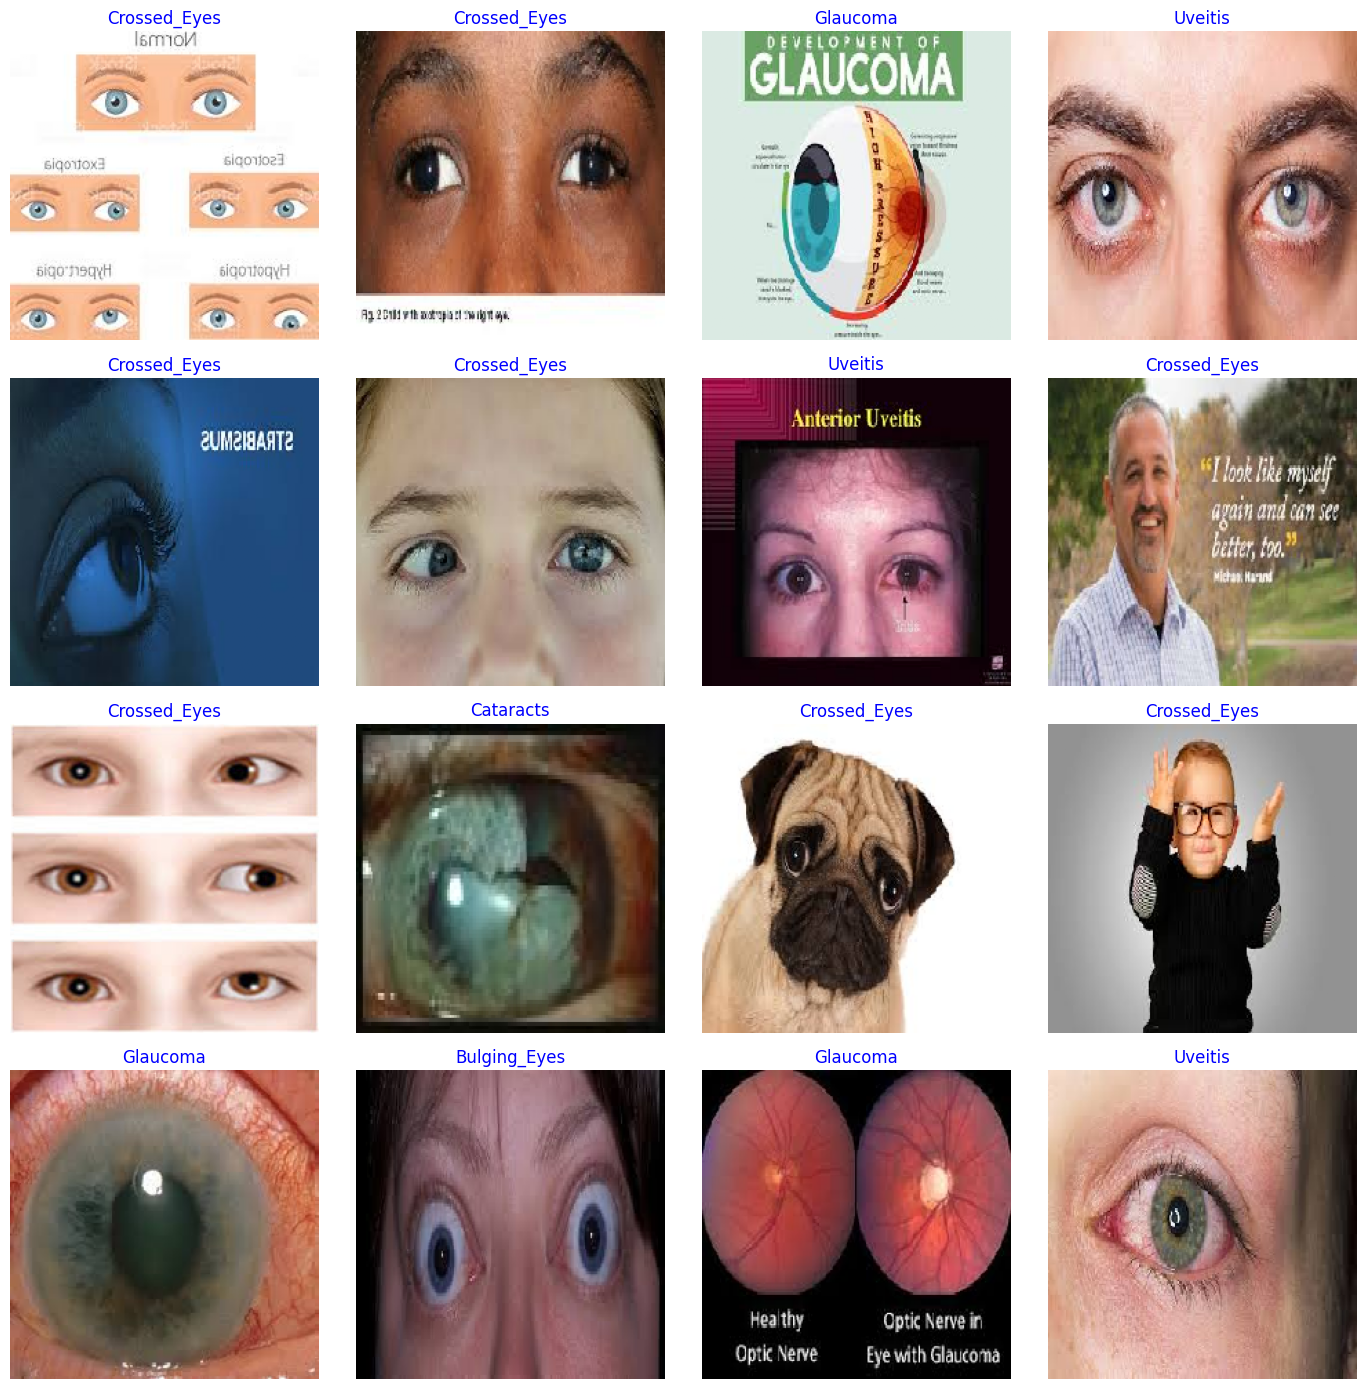

In [10]:
show_images(train_gen)

#### **Generic Model Creation**

In [11]:
# Create Model Structure
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adamax

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (EfficientNetB3)
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False, 
    weights='imagenet', 
    input_shape=img_shape, 
    pooling='max'
)

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(
        256, 
        kernel_regularizer=regularizers.l2(0.016), 
        activity_regularizer=regularizers.l1(0.006),
        bias_regularizer=regularizers.l1(0.006), 
        activation='relu'
    ),
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1791199040.381932     116 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791199040.385985     116 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,436 (42.67 MB)

 Trainable params: 11,094,061 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

#### **Set Callback Parameters**

In [12]:
# ====================================================================
# 🎯 CLINICAL MODEL TRAINING CALLBACKS (Automated & Non-Blocking)
# ====================================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

epochs = 30

# 1. Best Model Checkpoint (saves highest validation accuracy model)
checkpoint_cb = ModelCheckpoint(
    'best_eye_disease_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Dynamic Learning Rate Scheduler (prevents oscillation on plateaus)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# 3. Clinical Early Stopping (restores optimal weights upon convergence)
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_cb, reduce_lr_cb, early_stop_cb]
print('✅ Clinical training callbacks initialized: Checkpoint, ReduceLROnPlateau, EarlyStopping')


✅ Clinical training callbacks initialized: Checkpoint, ReduceLROnPlateau, EarlyStopping


#### **Train model**

In [13]:
# Train model with clean progress tracking and automated best model saving
history = model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    shuffle=False
)


Epoch 1/30


2026-10-05 11:18:42.853819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:18:43.004360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:18:43.410706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:18:43.561644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:18:44.465237: E external/local_xla/xla/stream_

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.3402 - loss: 38.0715

2026-10-05 11:20:08.653388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:20:08.798432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:20:09.178079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:20:09.331070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:20:09.482885: E external/local_xla/xla/stream_

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3430 - loss: 37.5657  

2026-10-05 11:21:20.773982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:21:20.924921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:21:21.329134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:21:21.480792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:21:22.358692: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_eye_disease_model.keras

Epoch 1: finished saving model to best_eye_disease_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 244s 15s/step - accuracy: 0.3627 - loss: 34.0252 - val_accuracy: 0.5000 - val_loss: 47.5775 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4885 - loss: 22.1122
Epoch 2: val_accuracy did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 381ms/step - accuracy: 0.4706 - loss: 19.8828 - val_accuracy: 0.3947 - val_loss: 30.6564 - learning_rate: 0.0010
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5185 - loss: 13.2470
Epoch 3: val_accuracy did not improve from 0.50000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 391ms/step - accuracy: 0.5359 - loss: 12.5235 - val_accuracy: 0.5000 - val_loss: 20.2046 - learning_rate: 0.0010
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.5234 - loss: 9.8774
Epoch 4: val_accuracy improved from 0.50000 to 0.55263, sa

#### **Display model performance**

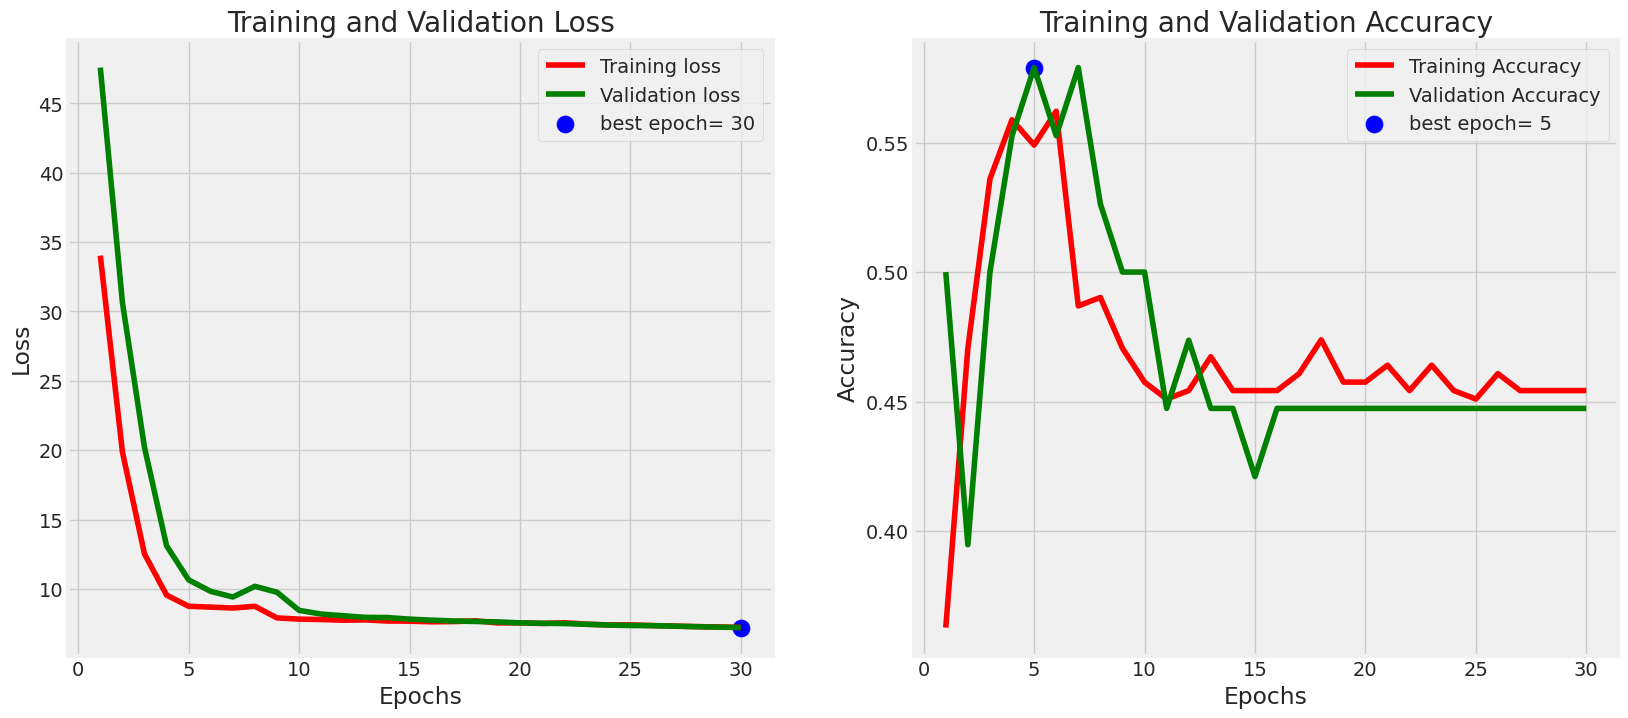

In [14]:
plot_training(history)

# **Evaluate model**

In [15]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)

print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.4750 - loss: 7.2268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.4474 - loss: 7.2193


2026-10-05 11:23:38.481594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:23:38.633916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:23:39.046686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:23:39.198934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 11:23:40.089801: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.4615 - loss: 7.2192
Train Loss:  7.226809501647949
Train Accuracy:  0.4749999940395355
--------------------
Validation Loss:  7.219298362731934
Validation Accuracy:  0.44736841320991516
--------------------
Test Loss:  7.219242095947266
Test Accuracy:  0.4615384638309479


# **Get Predictions**

In [16]:
preds = model.predict_generator(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

AttributeError: 'Sequential' object has no attribute 'predict_generator'

#### **Confusion Matrics and Classification Report**

In [ ]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm= cm, classes= classes, title = 'Confusion Matrix')

# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

#### **Save model**

In [ ]:
model_name = model.input_names[0][:-6]
subject = 'Eye Disease'
acc = test_score[1] * 100
save_path = ''

# Save model
save_id = str(f'{model_name}-{subject}-{"%.2f" %round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{model_name}-{subject}-weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')

#### **Generate CSV files containing classes indicies & image size**

In [ ]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

## 📥 Download Trained Model & Artifacts (Kaggle)

This cell standardizes the eye disease model naming (`eye_disease_model.h5`), packages the model weights and `Eye Disease-class_dict.csv` into a zip bundle, and displays direct download links.

In [ ]:
# ====================================================================
# 📥 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE
# ====================================================================
import os
import zipfile
from IPython.display import FileLink, display

saved_files = []

# 1. Save standardized model file name for direct integration
standard_model_name = 'eye_disease_model.h5'
if 'model' in globals():
    model.save(standard_model_name)
    saved_files.append(standard_model_name)
    print(f"✓ Saved standardized model: {standard_model_name}")

# 2. Collect existing saved model and class dictionary if present
if 'model_save_loc' in globals() and os.path.exists(model_save_loc):
    saved_files.append(model_save_loc)
if 'weights_save_loc' in globals() and os.path.exists(weights_save_loc):
    saved_files.append(weights_save_loc)
if 'csv_save_loc' in globals() and os.path.exists(csv_save_loc):
    saved_files.append(csv_save_loc)
elif os.path.exists('Eye Disease-class_dict.csv'):
    saved_files.append('Eye Disease-class_dict.csv')

# 3. Create zip bundle for 1-click download
zip_filename = 'eye_disease_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file_name in set(saved_files):
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
print(f"✓ Packaged bundle: {zip_filename}")

# 4. Generate Kaggle Direct Download Links
print("\n" + "="*50)
print("👉 Click the link below to download your complete model bundle:")
print("="*50)
display(FileLink(zip_filename))

print("\nIndividual file downloads:")
for file_name in set(saved_files):
    if os.path.exists(file_name):
        display(FileLink(file_name))
